In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from typing import Dict, Tuple, List
import ast
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from probeinterface import read_probeinterface
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from spikeinterface.core import concatenate_recordings
import warnings
warnings.filterwarnings('ignore')

# 常量
LEFT_SAMPLE = 10   # spike前10个采样点
RIGHT_SAMPLE = 20  # spike后20个采样点
WINDOW_SIZE = 30   # 总共30个采样点: [spike_time - 10, spike_time + 20)


In [2]:
# 设置路径
sorted_dir = Path("/media/ubuntu/sda/mouse_test/sorted/WLF_128chmouse1_natima_RHD_251129_183351_10k_kilosort")
spike_inf_path = sorted_dir / "spike_inf.tsv"
neuron_inf_path = sorted_dir / "neuron_inf.pkl"
raw_data_dir = Path("/media/ubuntu/sda/mouse_test/raw_data/WLF_128chmouse1_natima_RHD_251129_183351")
probe_file = Path("/media/ubuntu/sda/mouse_test/probe/tip_probe_128.json")

# 读取数据
print("读取spike_inf.tsv...")
spike_inf = pd.read_csv(spike_inf_path, sep='\t')
print(f"spike_inf shape: {spike_inf.shape}")
print(f"spike_inf columns: {spike_inf.columns.tolist()}")

print("\n读取neuron_inf.pkl...")
with open(neuron_inf_path, "rb") as f:
    neuron_inf = pickle.load(f)
print(f"neuron_inf shape: {neuron_inf.shape}")
print(f"neuron_inf columns: {neuron_inf.columns.tolist()}")
print(f"\n前几行neuron_inf:")
print(neuron_inf.head())


读取spike_inf.tsv...
spike_inf shape: (315424, 3)
spike_inf columns: ['cluster', 'time', 'neuron']

读取neuron_inf.pkl...
neuron_inf shape: (36, 7)
neuron_inf columns: ['Neuron', 'position_1', 'position_2', 'position_waveform', 'channel_id', 'cluster', 'tract_channel']

前几行neuron_inf:
      Neuron  position_1  position_2  \
0  Neuron_22   98.922306  410.238807   
1  Neuron_35  542.061988  460.800278   
2  Neuron_39  554.237770  505.686126   
3  Neuron_41  541.987616  461.161218   
4  Neuron_43  554.182623  505.805196   

                                   position_waveform             channel_id  \
0  [0.41912144, 0.26649353, 0.18005583, 0.0578375...       [20, 22, 23, 24]   
1  [-0.16165206, -0.405346, -0.65264624, -0.77907...      [2, 4, 7, 16, 17]   
2  [-0.2210386, -0.39960146, -0.70678365, -0.8719...  [2, 4, 7, 17, 45, 46]   
3  [0.024433553, 0.23267774, 0.32242587, 0.224583...      [2, 4, 7, 16, 17]   
4  [-0.28570378, -0.45211354, -0.4966044, -0.4625...  [2, 4, 7, 17, 45, 46]   

  

In [ ]:
def get_channel_positions_from_probe(probe) -> Dict[int, Tuple[float, float]]:
    """从probe对象中提取通道位置信息"""
    channel_positions = {}
    
    # 处理ProbeGroup
    if hasattr(probe, 'probes'):
        for probe_obj in probe.probes:
            contact_positions = probe_obj.contact_positions
            device_channel_indices = probe_obj.device_channel_indices
            if device_channel_indices is not None:
                for i, ch_idx in enumerate(device_channel_indices):
                    if ch_idx is not None and i < len(contact_positions):
                        channel_positions[int(ch_idx)] = tuple(contact_positions[i])
            else:
                contact_ids = probe_obj.contact_ids
                for i, contact_id in enumerate(contact_ids):
                    if i < len(contact_positions):
                        try:
                            ch_idx = int(contact_id)
                            channel_positions[ch_idx] = tuple(contact_positions[i])
                        except (ValueError, TypeError):
                            pass
    else:
        # 处理单个Probe对象
        contact_positions = probe.contact_positions
        device_channel_indices = probe.device_channel_indices
        if device_channel_indices is not None:
            for i, ch_idx in enumerate(device_channel_indices):
                if ch_idx is not None and i < len(contact_positions):
                    channel_positions[int(ch_idx)] = tuple(contact_positions[i])
        else:
            contact_ids = probe.contact_ids
            for i, contact_id in enumerate(contact_ids):
                if i < len(contact_positions):
                    try:
                        ch_idx = int(contact_id)
                        channel_positions[ch_idx] = tuple(contact_positions[i])
                    except (ValueError, TypeError):
                        pass
    
    return channel_positions

def parse_channel_id(channel_id_str):
    """解析channel_id字符串为整数列表"""
    # 处理None
    if channel_id_str is None:
        return []
    
    # 处理numpy数组或pandas Series
    if isinstance(channel_id_str, (np.ndarray, pd.Series)):
        # 检查是否全为NaN
        if isinstance(channel_id_str, np.ndarray):
            if channel_id_str.size == 0 or np.all(pd.isna(channel_id_str)):
                return []
            return channel_id_str.tolist()
        else:  # pd.Series
            if len(channel_id_str) == 0 or channel_id_str.isna().all():
                return []
            return channel_id_str.tolist()
    
    # 处理标量NaN值
    try:
        if pd.isna(channel_id_str):
            return []
    except (ValueError, TypeError):
        # 如果pd.isna抛出异常（比如是数组），继续处理
        pass
    
    # 处理字符串
    try:
        if isinstance(channel_id_str, str):
            return ast.literal_eval(channel_id_str)
        elif isinstance(channel_id_str, list):
            return channel_id_str
        else:
            return []
    except:
        return []

def compute_waveform_from_position(
    snippet: np.ndarray,
    channel_id: List[int],
    neuron_pos: Tuple[float, float],
    channel_positions: Dict[int, Tuple[float, float]]
) -> np.ndarray:
    """
    基于neuron位置和channel位置，使用IDW插值计算波形
    
    Args:
        snippet: (n_channels, window_size) 波形数据
        channel_id: 通道ID列表（必须与snippet的第一维大小一致）
        neuron_pos: (x, y) neuron位置
        channel_positions: 通道ID到(x, y)位置的映射
    
    Returns:
        position_waveform: (window_size,) 插值后的波形
    """
    # 安全检查：确保channel_id的长度与snippet的第一维大小一致
    if len(channel_id) != snippet.shape[0]:
        raise ValueError(f"channel_id长度({len(channel_id)})与snippet第一维大小({snippet.shape[0]})不匹配")
    
    neuron_x, neuron_y = neuron_pos
    distances = []
    
    for channel in channel_id:
        pos = channel_positions.get(channel, None)
        if pos is not None:
            x_channel, y_channel = pos
            if not (np.isnan(x_channel) or np.isnan(y_channel)):
                distance = np.sqrt((neuron_x - x_channel)**2 + (neuron_y - y_channel)**2)
                distances.append(distance)
            else:
                distances.append(np.inf)
        else:
            distances.append(np.inf)
    
    if not distances or all(d == np.inf for d in distances):
        return np.zeros(WINDOW_SIZE, dtype=np.float32)
    
    distances = np.array(distances, dtype=np.float32)
    
    # IDW插值计算position_waveform
    weights = 1.0 / (np.power(distances, 2, dtype=np.float32) + 1e-10)
    if np.any(distances == 0):
        zero_idx = np.where(distances == 0)[0][0]
        # 再次安全检查
        if zero_idx >= snippet.shape[0]:
            raise ValueError(f"zero_idx({zero_idx})超出snippet第一维大小({snippet.shape[0]})")
        position_waveform = snippet[zero_idx, :].astype(np.float32)
    else:
        weights /= weights.sum()
        position_waveform = np.zeros(WINDOW_SIZE, dtype=np.float32)
        for t in range(WINDOW_SIZE):
            position_waveform[t] = float(np.dot(snippet[:, t], weights))
    
    return position_waveform

def compute_correlation(waveform1: np.ndarray, waveform2: np.ndarray) -> float:
    """计算两个波形之间的pearson相关系数"""
    waveform1 = np.asarray(waveform1, dtype=np.float32)
    waveform2 = np.asarray(waveform2, dtype=np.float32)
    
    min_len = min(len(waveform1), len(waveform2))
    if min_len == 0:
        return 0.0
    
    corr, _ = pearsonr(waveform1[:min_len], waveform2[:min_len])
    
    if np.isnan(corr):
        return 0.0
    
    return float(corr)


In [4]:
# 加载probe文件
print("加载probe文件...")
probe = read_probeinterface(str(probe_file))
channel_positions = get_channel_positions_from_probe(probe)
print(f"加载了 {len(channel_positions)} 个通道的位置信息")


加载probe文件...
加载了 128 个通道的位置信息


In [5]:
# 加载recording数据
print("加载recording数据...")
rhd_files = sorted(raw_data_dir.glob("*.rhd"))
print(f"找到 {len(rhd_files)} 个RHD文件")

recording_raw_list = []
for rhd_file in rhd_files:
    try:
        recording_raw = se.read_intan(file_path=str(rhd_file), stream_id='0')
        recording_raw = spre.unsigned_to_signed(recording_raw)
        recording_raw_list.append(recording_raw)
    except Exception as e:
        print(f"警告: 无法加载 {rhd_file}: {e}")
        continue

if len(recording_raw_list) == 0:
    raise ValueError("没有成功加载任何recording文件")

# 连接所有recording
if len(recording_raw_list) > 1:
    recording_raw = concatenate_recordings(recording_raw_list)
else:
    recording_raw = recording_raw_list[0]

# 应用预处理
print("应用预处理...")
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording = spre.common_reference(recording_recorded, reference="global", operator="median")

# 设置probe
recording = recording.set_probegroup(probe)

print(f"Recording shape: {recording.get_num_channels()} channels, {recording.get_num_samples()} samples")
print(f"Sampling rate: {recording.get_sampling_frequency()} Hz")


加载recording数据...
找到 49 个RHD文件
应用预处理...
Recording shape: 128 channels, 58659584 samples
Sampling rate: 20000.0 Hz


In [6]:
# 准备neuron信息字典，方便快速查找
neuron_dict = {}
for idx, row in neuron_inf.iterrows():
    neuron = row['Neuron']
    neuron_dict[neuron] = {
        'position_1': row['position_1'],
        'position_2': row['position_2'],
        'position_waveform': np.asarray(row['position_waveform'], dtype=np.float32) if row['position_waveform'] is not None else None,
        'channel_id': parse_channel_id(row.get('channel_id', None))
    }

print(f"准备了 {len(neuron_dict)} 个neuron的信息")


准备了 36 个neuron的信息


In [12]:
# 获取recording的所有traces（一次性加载，避免重复读取）
print("加载recording traces...")
max_frame = recording.get_num_samples()
sampling_frequency = recording.get_sampling_frequency()
n_channels = recording.get_num_channels()

# 创建通道ID到索引的映射
recording_channel_ids = recording.get_channel_ids()
channel_id_to_index = {ch_id: idx for idx, ch_id in enumerate(recording_channel_ids)}
print(f"Recording有 {n_channels} 个通道")
print(f"Recording通道ID示例: {recording_channel_ids[:5]}...{recording_channel_ids[-5:]}")
print(f"通道ID类型: {type(recording_channel_ids[0])}")

# 为了节省内存，我们分批处理
# 先获取所有需要处理的spike时间
print("准备处理spike数据...")
# 使用字典存储每个neuron的相关性列表
correlations_dict = {}

# 按neuron分组处理
unique_neurons = spike_inf['neuron'].unique()
print(f"共有 {len(unique_neurons)} 个neuron需要处理")

# 限制处理的neuron数量（用于测试，可以注释掉以处理所有neuron）
# unique_neurons = unique_neurons[:5]  # 只处理前5个neuron用于测试

for neuron_idx, neuron in enumerate(unique_neurons):
    if neuron not in neuron_dict:
        continue
    
    neuron_info = neuron_dict[neuron]
    neuron_pos = (neuron_info['position_1'], neuron_info['position_2'])
    neuron_position_waveform = neuron_info['position_waveform']
    channel_id = neuron_info['channel_id']
    
    # 检查数据有效性
    if pd.isna(neuron_pos[0]) or pd.isna(neuron_pos[1]) or neuron_position_waveform is None:
        continue
    if len(channel_id) == 0:
        continue
    
    # 将channel_id映射到recording的通道索引，同时过滤掉不存在的通道
    channel_indices = []
    valid_channel_id = []  # 只保留成功映射的通道ID
    
    # 检查recording通道ID的格式
    first_ch_id = channel_id[0] if len(channel_id) > 0 else None
    first_recording_ch_id = recording_channel_ids[0] if len(recording_channel_ids) > 0 else None
    
    # 如果recording使用字符串格式的通道ID（如"C-000"），需要转换
    if isinstance(first_recording_ch_id, str) and isinstance(first_ch_id, int):
        # recording使用字符串格式，channel_id是整数
        # 尝试将整数转换为字符串格式
        for ch_id in channel_id:
            # 尝试多种可能的格式
            possible_formats = [
                f"C-{ch_id:03d}",  # C-000格式
                f"B-{ch_id:03d}",  # B-000格式
                f"A-{ch_id:03d}",  # A-000格式
                str(ch_id),        # 直接字符串
            ]
            
            found = False
            for ch_id_str in possible_formats:
                if ch_id_str in channel_id_to_index:
                    channel_indices.append(channel_id_to_index[ch_id_str])
                    valid_channel_id.append(ch_id)
                    found = True
                    break
            
            # 如果字符串格式都不匹配，尝试直接作为索引使用
            if not found and isinstance(ch_id, int) and 0 <= ch_id < n_channels:
                channel_indices.append(ch_id)
                valid_channel_id.append(ch_id)
    else:
        # recording和channel_id使用相同格式
        for ch_id in channel_id:
            if ch_id in channel_id_to_index:
                channel_indices.append(channel_id_to_index[ch_id])
                valid_channel_id.append(ch_id)
            else:
                # 如果channel_id不在recording中，尝试直接作为索引使用
                if isinstance(ch_id, int) and 0 <= ch_id < n_channels:
                    channel_indices.append(ch_id)
                    valid_channel_id.append(ch_id)
    
    if len(channel_indices) == 0:
        print(f"  neuron {neuron} 的channel_id无法映射到recording通道，跳过")
        continue
    
    # 使用过滤后的channel_id，确保与snippet的行数一致
    channel_id_filtered = valid_channel_id
    
    # 安全检查：确保channel_indices都在有效范围内，并同步更新channel_id
    valid_mask = [0 <= idx < n_channels for idx in channel_indices]
    channel_indices = [idx for i, idx in enumerate(channel_indices) if valid_mask[i]]
    channel_id_filtered = [ch_id for i, ch_id in enumerate(channel_id_filtered) if valid_mask[i]]
    
    if len(channel_indices) == 0:
        print(f"  neuron {neuron} 的channel_id无法映射到有效的recording通道索引，跳过")
        continue
    
    # 保存过滤后的channel_id和channel_indices（用于后续处理）
    neuron_channel_id = channel_id_filtered.copy()
    neuron_channel_indices = channel_indices.copy()
    
    # 获取该neuron的所有spike
    neuron_spikes = spike_inf[spike_inf['neuron'] == neuron]
    
    print(f"\n处理neuron {neuron} ({neuron_idx+1}/{len(unique_neurons)}): {len(neuron_spikes)} 个spikes")
    
    # 批量提取spike的waveform
    valid_spikes = []
    for _, spike_row in neuron_spikes.iterrows():
        spike_time = int(spike_row['time'])
        
        # 检查边界
        start = spike_time - LEFT_SAMPLE
        end = spike_time + RIGHT_SAMPLE
        
        if start < 0 or end > max_frame:
            continue
        if end - start != WINDOW_SIZE:
            continue
        
        valid_spikes.append(spike_time)
    
    if len(valid_spikes) == 0:
        print(f"  neuron {neuron} 没有有效的spikes")
        continue
    
    # 限制每个neuron处理的spike数量（用于测试，可以注释掉）
    # valid_spikes = valid_spikes[:100]  # 每个neuron只处理前100个spikes
    
    print(f"  提取 {len(valid_spikes)} 个有效spikes的waveform...")
    print(f"  channel_id: {neuron_channel_id[:10]}... (共{len(neuron_channel_id)}个)")
    print(f"  channel_indices: {neuron_channel_indices[:10]}... (共{len(neuron_channel_indices)}个)")
    
    # 初始化该neuron的相关性列表
    neuron_correlations = []
    
    # 批量提取waveform
    for spike_time in valid_spikes:
        start = spike_time - LEFT_SAMPLE
        end = spike_time + RIGHT_SAMPLE
        
        # 提取该spike的波形
        try:
            traces = recording.get_traces(start_frame=start, end_frame=end)
            # traces shape: (n_channels, window_size)
            
            # 使用neuron级别的channel_indices（每个spike都使用相同的通道）
            # 安全检查：确保所有channel_indices都在有效范围内
            max_valid_idx = traces.shape[0] - 1
            valid_indices = []
            valid_channel_id_local = []
            
            for i, idx in enumerate(neuron_channel_indices):
                if 0 <= idx <= max_valid_idx:
                    valid_indices.append(idx)
                    valid_channel_id_local.append(neuron_channel_id[i])
            
            if len(valid_indices) == 0:
                continue
            
            # 选择channel_indices对应的通道
            snippet = traces[valid_indices, :]  # (n_selected_channels, window_size)
            
            # 再次安全检查：确保snippet的行数与channel_id的长度一致
            if snippet.shape[0] != len(valid_channel_id_local):
                print(f"  警告: snippet行数({snippet.shape[0]})与channel_id长度({len(valid_channel_id_local)})不匹配，跳过")
                continue
            
            # 基于neuron的位置和channel位置计算权重，然后计算waveform
            computed_waveform = compute_waveform_from_position(
                snippet, valid_channel_id_local, neuron_pos, channel_positions
            )
            
            # 计算与neuron的position_waveform的相关性
            correlation = compute_correlation(computed_waveform, neuron_position_waveform)
            
            # 添加到该neuron的相关性列表
            neuron_correlations.append(correlation)
            
        except Exception as e:
            print(f"  警告: 处理spike {spike_time} 时出错: {e}")
            continue
    
    # 将该neuron的相关性列表存储到字典中
    if len(neuron_correlations) > 0:
        correlations_dict[neuron] = neuron_correlations
        print(f"  neuron {neuron} 计算了 {len(neuron_correlations)} 个spike的相关性")
    
    if (neuron_idx + 1) % 10 == 0:
        print(f"  已处理 {neuron_idx + 1}/{len(unique_neurons)} neurons, 当前neuron数量: {len(correlations_dict)}")

print(f"\n总共处理了 {len(correlations_dict)} 个neuron")
total_spikes = sum(len(corrs) for corrs in correlations_dict.values())
print(f"总共计算了 {total_spikes} 个spike的相关性")


加载recording traces...
Recording有 128 个通道
Recording通道ID示例: ['B-000' 'B-001' 'B-002' 'B-003' 'B-004']...['B-123' 'B-124' 'B-125' 'B-126' 'B-127']
通道ID类型: <class 'numpy.str_'>
准备处理spike数据...
共有 36 个neuron需要处理

处理neuron Neuron_22 (1/36): 1765 个spikes
  提取 1765 个有效spikes的waveform...
  channel_id: [20, 22, 23, 24]... (共4个)
  channel_indices: [20, 22, 23, 24]... (共4个)
  neuron Neuron_22 计算了 1765 个spike的相关性

处理neuron Neuron_35 (2/36): 12993 个spikes
  提取 12993 个有效spikes的waveform...
  channel_id: [2, 4, 7, 16, 17]... (共5个)
  channel_indices: [2, 4, 7, 16, 17]... (共5个)
  neuron Neuron_35 计算了 12993 个spike的相关性

处理neuron Neuron_39 (3/36): 2115 个spikes
  提取 2115 个有效spikes的waveform...
  channel_id: [2, 4, 7, 17, 45, 46]... (共6个)
  channel_indices: [2, 4, 7, 17, 45, 46]... (共6个)
  neuron Neuron_39 计算了 2115 个spike的相关性

处理neuron Neuron_41 (4/36): 7600 个spikes
  提取 7600 个有效spikes的waveform...
  channel_id: [2, 4, 7, 16, 17]... (共5个)
  channel_indices: [2, 4, 7, 16, 17]... (共5个)
  neuron Neuron_41 计算了 7600 

In [ ]:
# 查看统计信息
all_correlations = []
for neuron, corrs in correlations_dict.items():
    all_correlations.extend(corrs)

all_correlations = np.array(all_correlations)
print("所有spike的相关性统计信息:")
print(f"相关性数量: {len(all_correlations)}")
print(f"平均相关性: {np.mean(all_correlations):.4f}")
print(f"中位数相关性: {np.median(all_correlations):.4f}")
print(f"标准差: {np.std(all_correlations):.4f}")
print(f"最小值: {np.min(all_correlations):.4f}")
print(f"最大值: {np.max(all_correlations):.4f}")

print(f"\n各neuron的相关性统计:")
for neuron, corrs in correlations_dict.items():
    corrs_arr = np.array(corrs)
    print(f"  {neuron}: {len(corrs)} spikes, 平均={np.mean(corrs_arr):.4f}, 中位数={np.median(corrs_arr):.4f}")


相关性统计信息:
count    77973.000000
mean        -0.000346
std          0.227182
min         -0.718591
25%         -0.163345
50%          0.000363
75%          0.162025
max          0.785875
Name: correlation, dtype: float64

相关性数量: 77973
平均相关性: -0.0003
中位数相关性: 0.0004
标准差: 0.2272


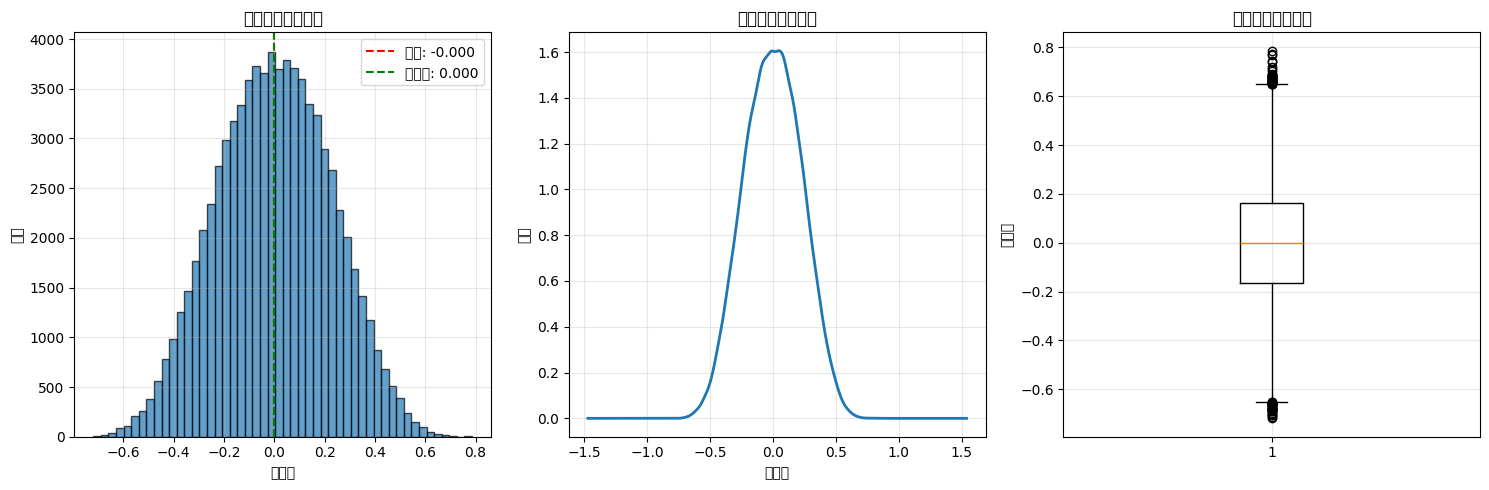

In [ ]:
# 可视化相关性分布
plt.figure(figsize=(15, 5))

# 1. 直方图
plt.subplot(1, 3, 1)
plt.hist(correlations_df['correlation'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('相关性')
plt.ylabel('频数')
plt.title('相关性分布直方图')
plt.grid(True, alpha=0.3)
plt.axvline(correlations_df['correlation'].mean(), color='r', linestyle='--', label=f'均值: {correlations_df["correlation"].mean():.3f}')
plt.axvline(correlations_df['correlation'].median(), color='g', linestyle='--', label=f'中位数: {correlations_df["correlation"].median():.3f}')
plt.legend()

# 2. 密度图
plt.subplot(1, 3, 2)
correlations_df['correlation'].plot(kind='density', linewidth=2)
plt.xlabel('相关性')
plt.ylabel('密度')
plt.title('相关性分布密度图')
plt.grid(True, alpha=0.3)

# 3. 箱线图
plt.subplot(1, 3, 3)
plt.boxplot(correlations_df['correlation'], vert=True)
plt.ylabel('相关性')
plt.title('相关性分布箱线图')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


各neuron的平均相关性（前20个）:
       neuron      mean    median       std  count
0   Neuron_22  0.008313  0.007753  0.223702   1765
5   Neuron_44  0.002094  0.002731  0.204302   6722
10  Neuron_68  0.001471  0.004847  0.184570   5307
6   Neuron_46  0.000916  0.000429  0.260023   4202
7   Neuron_59  0.000249 -0.004800  0.196558   1886
4   Neuron_43  0.000236  0.001673  0.240465  19280
9   Neuron_66 -0.000049  0.002436  0.229507   2994
3   Neuron_41 -0.000372 -0.000930  0.217296   7600
11  Neuron_69 -0.001337 -0.001466  0.216225   8641
1   Neuron_35 -0.001397 -0.000072  0.222969  12993
2   Neuron_39 -0.005845 -0.004680  0.204223   2115
8   Neuron_62 -0.006126 -0.011161  0.279178   4468


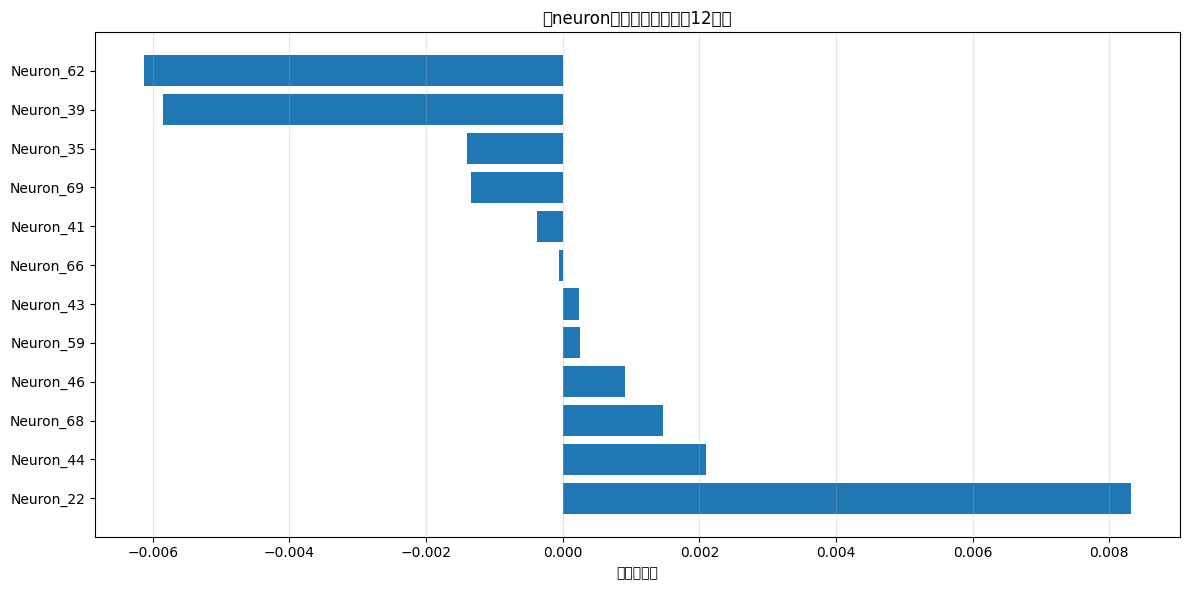

In [ ]:
# 按neuron分组查看相关性分布
neuron_corr_stats = correlations_df.groupby('neuron')['correlation'].agg(['mean', 'median', 'std', 'count']).reset_index()
neuron_corr_stats = neuron_corr_stats.sort_values('mean', ascending=False)

print("各neuron的平均相关性（前20个）:")
print(neuron_corr_stats.head(20))

# 可视化各neuron的平均相关性
plt.figure(figsize=(12, 6))
top_n = min(30, len(neuron_corr_stats))
plt.barh(range(top_n), neuron_corr_stats.head(top_n)['mean'].values)
plt.yticks(range(top_n), neuron_corr_stats.head(top_n)['neuron'].values)
plt.xlabel('平均相关性')
plt.title(f'各neuron的平均相关性（前{top_n}个）')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


In [ ]:
# 保存结果
output_path = sorted_dir / "spike_correlations.csv"
correlations_df.to_csv(output_path, index=False)
print(f"结果已保存到: {output_path}")

# 保存按neuron统计的结果
neuron_stats_path = sorted_dir / "neuron_correlation_stats.csv"
neuron_corr_stats.to_csv(neuron_stats_path, index=False)
print(f"Neuron统计结果已保存到: {neuron_stats_path}")


结果已保存到: /media/ubuntu/sda/mouse_test/sorted/WLF_128chmouse1_natima_RHD_251129_183351_10k_kilosort/spike_correlations.csv
Neuron统计结果已保存到: /media/ubuntu/sda/mouse_test/sorted/WLF_128chmouse1_natima_RHD_251129_183351_10k_kilosort/neuron_correlation_stats.csv
